## Imports

In [35]:
import matplotlib.pyplot as plt
import numpy as np

from pygenn import GeNNModel, VarAccess
from pygenn import (create_neuron_model, create_var_ref, create_weight_update_model, 
                    init_postsynaptic, init_weight_update)

## Parameters

In [36]:
PRE_RATE = 50.0
POST_RATE = 50.0
NUM_POST_STIM = 256

ETA = 0.001

DURATION_MS = 1000
TAU = 20.0
V_THRESH = 0.6

STIM_WEIGHT = 0.0025


## PyGeNN models

In [75]:
lif_model = create_neuron_model(
    "lif",
    params=["TauM", "Vthresh", "TauRefrac"],
    vars=[("V", "scalar"), ("RefracTime", "scalar"), ("E", "scalar"), ("Echange", "bool")],
    derived_params=[("Alpha", lambda pars, dt: np.exp(-dt / pars["TauM"]))],
    extra_global_params=[("EVec", "scalar*")],
    sim_code="""
    E = EVec[(int)t];
    V = (Alpha * V) + Isyn;
    if (RefracTime > 0.0) {
      RefracTime -= dt;
    }
    
    """,
    reset_code="""
    RefracTime = TauRefrac;
    V -= Vthresh;
    """,
    threshold_condition_code="""
    RefracTime <= 0.0 && V >= Vthresh
    """)
    
eprop_lif_time_model = create_weight_update_model(
    "eprop_lif_time",
    params=["TauE", "Eta"],
    derived_params=[("Alpha", lambda pars, dt: np.exp(-dt / pars["TauE"]))],
    vars=[("g", "scalar"), ("eFiltered", "scalar")],
    pre_vars=[("ZFilter", "scalar")],
    post_vars=[("Psi", "scalar")],
    post_neuron_var_refs=[("RefracTime_post", "scalar"), ("V_post", "scalar"), ("E_post", "scalar")],

    pre_spike_code="""
    ZFilter += 1.0;
    """,
    pre_dynamics_code="""
    ZFilter *= Alpha;
    """,

    post_dynamics_code="""
    if (RefracTime_post > 0.0) {
      Psi = 0.0;
    }
    else {
      Psi = (V_post > 0.3) ? 0.5 : 0.0;
    }
    """,

    synapse_dynamics_code="""
    const scalar e = ZFilter * Psi;
    scalar eF = eFiltered;
    eF = (eF * Alpha) + e;
    g += Eta * eF * E_post;
    eFiltered = eF;
    """)

eprop_lif_event_model = create_weight_update_model(
    "eprop_lif_event",
    params=["TauE", "Eta"],
    vars=[("g", "scalar"), ("eFiltered", "scalar")],
    pre_vars=[("ZFilter", "scalar")],
    post_vars=[("Psi", "scalar"), ("PsiChange", "bool")],
    post_neuron_var_refs=[("RefracTime_post", "scalar"), ("V_post", "scalar"), 
                          ("E_post", "scalar"), ("Echange_post", "bool")],
    
    pre_spike_syn_code="""
    // Get last update time
    // **NOTE** this happens before any postsynaptic update so use prev_set_post
    const timepoint lastUpdateTime = max(prev_st_pre, prev_set_post);
    
    const scalar decay = exp(-(t - lastUpdateTime) / TauE);
    const scalar tauDecay = TauE * decay;
    const scalar tauDecayMinusOne = TauE * (decay - 1.0);

    // Update weight
    g += -Eta * E_post * (
        Psi * ZFilter * ((TauE * (TauE + lastUpdateTime)) - (tauDecay * (t + TauE))
                         + lastUpdateTime * tauDecayMinusOne)
        - (eFiltered * tauDecayMinusOne))

    // Update E
    eFiltered = ((t - lastUpdateTime) * Psi * ZFilter * tauDecay) + (eFiltered * tauDecay);vent * exp_delta_t)
    """,
    
    post_event_syn_code="""
    // **NOTE** this happens after a potential presynaptic update so use st_pre
    const timepoint lastUpdateTime = max(st_pre, prev_set_post);
    
    const scalar decay = exp(-(t - lastUpdateTime) / TauE);
    const scalar tauDecay = TauE * decay;
    const scalar tauDecayMinusOne = TauE * (decay - 1.0);

    // Update weight
    g += -Eta * E_post * (
        Psi * ZFilter * ((TauE * (TauE + lastUpdateTime)) - (tauDecay * (t + TauE))
                         + lastUpdateTime * tauDecayMinusOne)
        - (eFiltered * tauDecayMinusOne))

    // Update E
    eFiltered = ((t - lastUpdateTime) * Psi * ZFilter * tauDecay) + (eFiltered * tauDecay);vent * exp_delta_t)
    """,
    
    post_event_threshold_condition_code="""
    Echange_post || PsiChange
    """,
    
    pre_spike_code="""
    const scalar dt = t - st_pre;
    ZFilter = ZFilter * exp(-dt / TauE) + 1.0;
    """,

    post_dynamics_code="""
    scalar newPsi;
    if (RefracTime_post > 0.0) {
      newPsi = 0.0;
    }
    else {
      newPsi = (V_post > 0.3) ? 0.5 : 0.0;
    }
    
    PsiChange = (newPsi != Psi);
    Psi = newPsi;
    """)

## PyGeNN network

In [76]:
model = GeNNModel("float", "event_based_eprop_proto", backend="single_threaded_cpu")
model.dt = 1.0

pre = model.add_neuron_population("Pre", 1, "PoissonNew", 
                                  {"rate": PRE_RATE}, 
                                  {"timeStepToSpike": 0})
pre.spike_recording_enabled = True
post = model.add_neuron_population("Post", 1, lif_model, 
                                   {"TauM": TAU, "Vthresh": V_THRESH, "TauRefrac": 5.0},
                                   {"V": 0.0, "RefracTime": 0.0, "E": 0.0, "Echange": False})
post.spike_recording_enabled = True
post.spike_event_recording_enabled = True
post_stim = model.add_neuron_population("PostStim", NUM_POST_STIM, "PoissonNew",
                                        {"rate": POST_RATE},
                                        {"timeStepToSpike": 0.0})

post_stim_post = model.add_synapse_population("PostStim_Post", "DENSE",
                                              post_stim, post,
                                              init_weight_update("StaticPulseConstantWeight", {"g": STIM_WEIGHT}),
                                              init_postsynaptic("DeltaCurr"))

# Add time-driven e-prop synapse
pre_post_time = model.add_synapse_population("Pre_Post_time", "DENSE",
                                             pre, post,
                                             init_weight_update(eprop_lif_time_model, {"TauE": TAU, "Eta": ETA},
                                                                {"g": 0.0, "eFiltered": 0.0},
                                                                 pre_vars={"ZFilter": 0.0}, post_vars={"Psi": 0.0},
                                                                 post_var_refs={"RefracTime_post": create_var_ref(post, "RefracTime"),
                                                                                "V_post": create_var_ref(post, "V"),
                                                                                "E_post": create_var_ref(post, "E")}),
                                            init_postsynaptic("DeltaCurr"))

# Add event-driven e-prop synapse
pre_post_event = model.add_synapse_population("Pre_Post_event", "DENSE",
                                              pre, post,
                                              init_weight_update(eprop_lif_event_model, {"TauE": TAU, "Eta": ETA},
                                                                {"g": 0.0, "eFiltered": 0.0},
                                                                 pre_vars={"ZFilter": 0.0}, post_vars={"Psi": 0.0, "PsiChange": False},
                                                                 post_var_refs={"RefracTime_post": create_var_ref(post, "RefracTime"),
                                                                                "V_post": create_var_ref(post, "V"),
                                                                                "E_post": create_var_ref(post, "E"),
                                                                                "Echange_post": create_var_ref(post, "Echange")}),
                                            init_postsynaptic("DeltaCurr"))

model.build()

learning_signal = np.concatenate((np.ones(DURATION_MS // 4), 
                                  np.zeros(DURATION_MS // 4),
                                  -np.ones(DURATION_MS // 4), 
                                  np.ones(DURATION_MS // 4) * 0.5))
post.extra_global_params["EVec"].set_init_values(learning_signal)

model.load(num_recording_timesteps=int(DURATION_MS))

2024-01-10 16:40:17.852 ERROR [32075] [GeNN::Transpiler::ErrorHandler::report@28] [Synapse group 'Pre_Post_event' weight update model sim code, line 4] Error at 'timepoint': missing type specifier
2024-01-10 16:40:17.852 ERROR [32075] [GeNN::Transpiler::ErrorHandler::report@28] [Synapse group 'Pre_Post_event' weight update model sim code, line 17] Error at 'eFiltered': Expect ';' after expression
2024-01-10 16:40:17.852 ERROR [32075] [GeNN::Transpiler::ErrorHandler::report@28] [Synapse group 'Pre_Post_event' weight update model sim code, line 17] Error at ')': Expect ';' after expression


RuntimeError: Parse error Synapse group 'Pre_Post_event' weight update model sim code

## Simulation

In [74]:

e = []
e_filtered = []
g = []
w = []
z_filter_pre = []
v_post = []
psi_post = []
model.timestep = 0
while model.t < DURATION_MS:
    model.step_time()
    
    # Post vars
    post.vars["V"].pull_from_device()
    post.vars["E"].pull_from_device()
    v_post.append(post.vars["V"].view[0])
    e.append(post.vars["E"].view[0])
    
    # Time-driven e-prop vars
    pre_post_time.pre_vars["ZFilter"].pull_from_device()
    pre_post_time.post_vars["Psi"].pull_from_device()
    pre_post_time.vars["g"].pull_from_device()
    pre_post_time.vars["eFiltered"].pull_from_device()
    
    z_filter_pre.append(pre_post_time.pre_vars["ZFilter"].view[0])
    psi_post.append(pre_post_time.post_vars["Psi"].view[0])
    g.append(pre_post_time.vars["g"].view[0])
    e_filtered.append(pre_post_time.vars["eFiltered"].view[0])

model.pull_recording_buffers_from_device()
pre_spike_times, _ = pre.spike_recording_data[0]
post_spike_times, _ = post.spike_recording_data[0]

post_spike_event_times, _ = pre_post_event.post_spike_event_recording_data[0]

IndexError: _Map_base::at

## Visualization

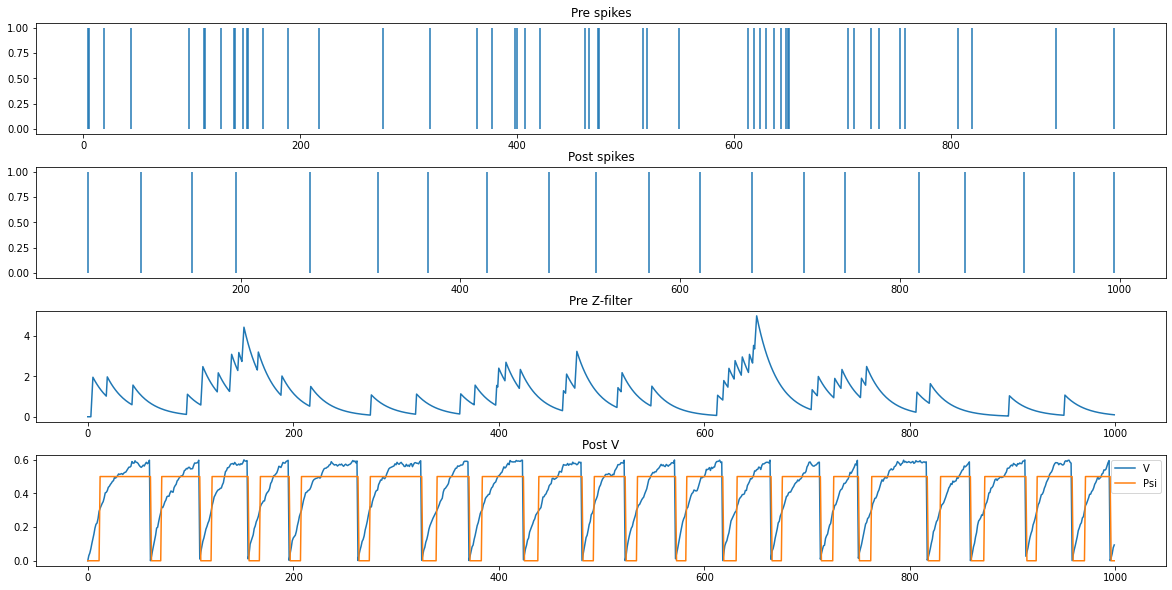

In [71]:
fig, axes = plt.subplots(4, figsize=(16, 8))
axes[0].set_title("Pre spikes")
axes[0].vlines(pre_spike_times, ymin=0, ymax=1)

axes[1].set_title("Post spikes")
axes[1].vlines(post_spike_times, ymin=0, ymax=1)

axes[2].set_title("Pre Z-filter")
axes[2].plot(z_filter_pre)

axes[3].set_title("Post V")
axes[3].plot(v_post, label="V")
axes[3].plot(psi_post, label="Psi")
axes[3].legend()
fig.tight_layout(pad=0)

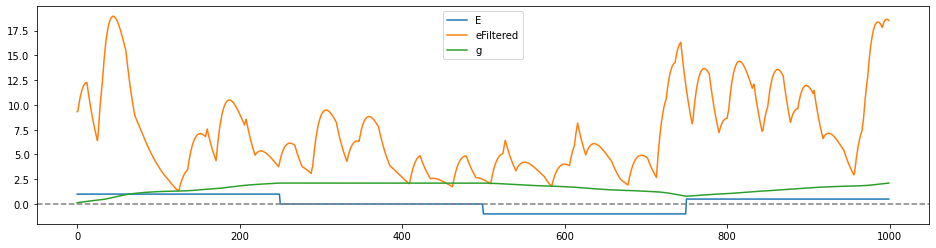

In [62]:
fig, axis = plt.subplots(figsize=(16, 4))
axis.plot(e, label="E")
axis.plot(e_filtered, label="eFiltered")
axis.plot(g, label="g")
axis.axhline(0, linestyle="--", color="gray")
axis.legend()